This notebook shows waveform mismatch for low $R_{orbit}$ values (20~100 $R_S$). The waveforms are also explicitly plotted out to confirm the waveform (mis)alignment at the troughs (peaks) of the mismatch curve.

In [60]:
import os
import sys
import copy
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

SCRIPT_DIR = os.path.dirname(os.path.realpath(os.path.join(os.path.dirname(os.getcwd()))))
sys.path.append(SCRIPT_DIR)

from gwfast.gwfastGlobals import detectors as det_dict, detPath
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.new_signal import NewGWSignal
from gwfast.AGN_lensed_signal import AGNLensedGWSignal
import gwfast.network as network
import gwfast.lensing_utils as lutils

In [3]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

# Using a simple waveform for now in the interest of time
wf_model = waveforms.IMRPhenomD()

H1_BBH = NewGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_BBH = NewGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_BBH = NewGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_BBH = network.DetNet({'H1': H1_BBH, 'L1': L1_BBH, 'V1': V1_BBH})

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


In [25]:
# Define a benchmark event
n = 150
shape = (n,)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 'dL':np.full(shape, 0.8), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 'tcoal':np.full(shape, 0), 'Phicoal':np.full(shape, 2), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 'chi1x':np.full(shape, 0), 'chi2x':np.full(shape, 0), 'chi1y':np.full(shape, 0), 'chi2y':np.full(shape, 0), 
    'LambdaTilde':np.full(shape, 0), 'deltaLambda':np.full(shape, 0), 'ecc':np.full(shape, 0), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.3)
}
events = {key: val.astype(np.float64) for key, val in events.items()}

# Compute benchmark SNR
event = {key: values[0] for key, values in events.items()}
HLV_BBH_SNR = HLV_BBH.SNR(event)
HLV_AGN_SNR = HLV_AGN.SNR(event)
print('SNR without lensing:', HLV_BBH_SNR, "\nSNR with lensing:", HLV_AGN_SNR)

SNR without lensing: 25.698484636691628 
SNR with lensing: 36.96321209625262


In [61]:
lutils.lens(events)

Image 1 parameters: {'Mc': Array([30.41131769, 30.41131769, 30.41131769, 30.41131769, 30.41131769,
       30.41131769, 30.41131769, 30.41131769, 30.41131769, 30.41131769,
       30.41131769, 30.41131769, 30.41131769, 30.41131769, 30.41131769,
       30.41131769, 30.41131769, 30.41131769, 30.41131769, 30.41131769,
       30.41131769, 30.41131769, 30.41131769, 30.41131769, 30.41131769,
       30.41131769, 30.41131769, 30.41131769, 30.41131769, 30.41131769,
       30.41131769, 30.41131769, 30.41131769, 30.41131769, 30.41131769,
       30.41131769, 30.41131769, 30.41131769, 30.41131769, 30.41131769,
       30.41131769, 30.41131769, 30.41131769, 30.41131769, 30.41131769,
       30.41131769, 30.41131769, 30.41131769, 30.41131769, 30.41131769,
       30.41131769, 30.41131769, 30.41131769, 30.41131769, 30.41131769,
       30.41131769, 30.41131769, 30.41131769, 30.41131769, 30.41131769,
       30.41131769, 30.41131769, 30.41131769, 30.41131769, 30.41131769,
       30.41131769, 30.41131769, 30.4

In [26]:
# Waveform metadata
sampling_frequency = 1024.  # Hz
minimum_frequency = 10.  # Hz
maximum_frequency = sampling_frequency / 2
N_freq_bins = 1000

# Make frequency grid
minimum_frequency_array = np.full(shape, minimum_frequency)
maximum_frequency_array = np.full(shape, maximum_frequency)
freq_grid = np.geomspace(minimum_frequency_array, maximum_frequency_array, N_freq_bins)

# Interpolate PSD
freq_array = np.geomspace(minimum_frequency, maximum_frequency, N_freq_bins)
psd_interp = np.interp(freq_array, L1.psd_frequencies, L1.psd_array)
psd_interp_grid = np.reshape(np.repeat(psd_interp, n), (-1, n))

In [27]:
# Mismatch definition
def inner_product(frequencies, h1, h2, psd):
    integrand = np.conj(h1) * h2 / psd
    return 4 * np.real(np.trapz(integrand, frequencies, axis=0))

def mismatch(frequencies, h1, h2, psd):
    return inner_product(frequencies, h1-h2, h1-h2, psd) / (2 * (inner_product(frequencies, h1, h1, psd) + inner_product(frequencies, h2, h2, psd)))

In [28]:
# Sample R_orbit values
R_orbit_array = np.linspace(20, 100, n)

# Pick Mc values
Mc_1 = np.full(n, 30)
Mc_2 = np.full(n, 50)
Mc_3 = np.full(n, 80)

# M_lz doesn't seem to affect mismatch, so fix it at benchmark value (1e4 M_sun)
# Similar for src_pos, fixed at 0.3

In [29]:
# Prepare injections
events_copy = events.copy()
events_copy['R_orbit'] = R_orbit_array

events_copy_1 = events_copy.copy()
events_copy_1['Mc'] = Mc_1
events_copy_2 = events_copy.copy()
events_copy_2['Mc'] = Mc_2
events_copy_3 = events_copy.copy()
events_copy_3['Mc'] = Mc_3

# Generate strains from L1
FD_strain_unlensed_1 = L1_BBH.GWstrain(freq_grid, events_copy_1)
FD_strain_lensed_1 = L1_AGN.GWstrain(freq_grid, events_copy_1)

FD_strain_unlensed_2 = L1_BBH.GWstrain(freq_grid, events_copy_2)
FD_strain_lensed_2 = L1_AGN.GWstrain(freq_grid, events_copy_2)

FD_strain_unlensed_3 = L1_BBH.GWstrain(freq_grid, events_copy_3)
FD_strain_lensed_3 = L1_AGN.GWstrain(freq_grid, events_copy_3)

# Compute mismatch
mismatch_1 = mismatch(freq_grid, FD_strain_lensed_1, FD_strain_unlensed_1, psd_interp_grid)
mismatch_2 = mismatch(freq_grid, FD_strain_lensed_2, FD_strain_unlensed_2, psd_interp_grid)
mismatch_3 = mismatch(freq_grid, FD_strain_lensed_3, FD_strain_unlensed_3, psd_interp_grid)

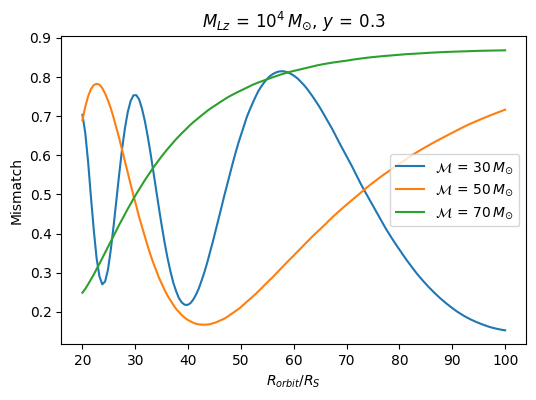

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.plot(R_orbit_array, mismatch_1, label=r'${\cal M}\,=\,30\,M_{\odot}$')
ax.plot(R_orbit_array, mismatch_2, label=r'${\cal M}\,=\,50\,M_{\odot}$')
ax.plot(R_orbit_array, mismatch_3, label=r'${\cal M}\,=\,70\,M_{\odot}$')
ax.set_xlabel(r'$R_{orbit}/R_S$')
ax.set_ylabel('Mismatch')
ax.set_title(r'$M_{Lz}\,=\,10^4\,M_{\odot},\,y\,=\,0.3$')
ax.legend()

# Check waveforms

Let's see what's happening at $\mathcal{M}=30M_{\odot}, R_{orbit}=31R_S$ to produce a high mismatch, as well as the same $\mathcal{M}$ at $R_{orbit}=40R_S$ to produce a low mismatch.

In [70]:
index_R_31 = np.argmin(np.abs(R_orbit_array - 31))
index_R_40 = np.argmin(np.abs(R_orbit_array - 40))

In [71]:
# We want to see time domain strain, so we'll use the method for creating coupled time and frequency arrays

# Waveform metadata
sampling_frequency = 1024.  # Hz
duration = 10.  # s

minimum_frequency = 10.  # Hz
## This maximum frequency need not equal to fs/2
maximum_frequency = sampling_frequency / 2

# This procedure to create coupled time and freq arrays is borrowed from Bilby
N_samples = int(np.round(duration * sampling_frequency))
N_freq_bins = int(np.round(N_samples / 2) + 1)
freq_array = np.linspace(0, sampling_frequency / 2, N_freq_bins)
time_array = np.linspace(0, duration - 1 / sampling_frequency, N_samples)

FD_strain_lensed_R_31 = np.zeros_like(freq_array, dtype='complex128')
FD_strain_unlensed_R_31 = np.zeros_like(freq_array, dtype='complex128')
FD_strain_lensed_R_40 = np.zeros_like(freq_array, dtype='complex128')
FD_strain_unlensed_R_40 = np.zeros_like(freq_array, dtype='complex128')

freq_mask = (freq_array > minimum_frequency) * (freq_array < maximum_frequency)
masked_freq_arr = freq_array[freq_mask]

FD_strain_lensed_R_31[freq_mask] = \
    L1_AGN.GWstrain(masked_freq_arr, {key: values[index_R_31] for key, values in events_copy_1.items()})
FD_strain_unlensed_R_31[freq_mask] = \
    L1_BBH.GWstrain(masked_freq_arr, {key: values[index_R_31] for key, values in events_copy_1.items()})
FD_strain_lensed_R_40[freq_mask] = \
    L1_AGN.GWstrain(masked_freq_arr, {key: values[index_R_40] for key, values in events_copy_1.items()})
FD_strain_unlensed_R_40[freq_mask] = \
    L1_BBH.GWstrain(masked_freq_arr, {key: values[index_R_40] for key, values in events_copy_1.items()})

TD_strain_lensed_R_31 = np.fft.irfft(FD_strain_lensed_R_31)
TD_strain_unlensed_R_31 = np.fft.irfft(FD_strain_unlensed_R_31)
TD_strain_lensed_R_40 = np.fft.irfft(FD_strain_lensed_R_40)
TD_strain_unlensed_R_40 = np.fft.irfft(FD_strain_unlensed_R_40)

# # Wrap ringdown to the end
# # TODO: Need to check how does GWstrain define the peak time
post_merger_time = -2
n_index = int(post_merger_time * sampling_frequency)
TD_strain_lensed_R_31 = np.roll(TD_strain_lensed_R_31, n_index)
TD_strain_unlensed_R_31 = np.roll(TD_strain_unlensed_R_31, n_index)
TD_strain_lensed_R_40 = np.roll(TD_strain_lensed_R_40, n_index)
TD_strain_unlensed_R_40 = np.roll(TD_strain_unlensed_R_40, n_index)

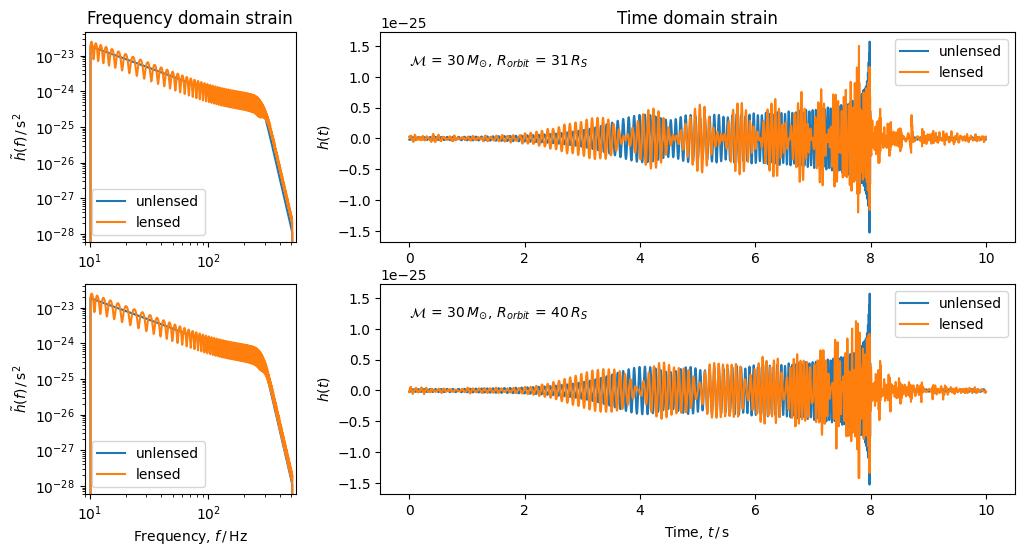

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6),  width_ratios=(1, 3))

ax = axes[0, 0]
ax.loglog(freq_array, np.abs(FD_strain_unlensed_R_31), label='unlensed')
ax.loglog(freq_array, np.abs(FD_strain_lensed_R_31), label='lensed')
ax.set_title('Frequency domain strain')
ax.set_ylabel(r'$\tilde{h}(f)\,/\,{\rm s}^2$')
ax.set_xlim(9, 550)

ax = axes[0, 1]
ax.plot(time_array, TD_strain_unlensed_R_31, label='unlensed')
ax.plot(time_array, TD_strain_lensed_R_31, label='lensed')
ax.set_title('Time domain strain')
ax.set_ylabel(r'$h(t)$')
ax.text(0, 1.2e-25, r'$\mathcal{M}\,=\,30\,M_{\odot},\,R_{orbit}\,=\,31\,R_S$')

ax = axes[1, 0]
ax.loglog(freq_array, np.abs(FD_strain_unlensed_R_40), label='unlensed')
ax.loglog(freq_array, np.abs(FD_strain_lensed_R_40), label='lensed')
ax.set_xlabel(r'Frequency, $f\,/\,{\rm Hz}$')
ax.set_ylabel(r'$\tilde{h}(f)\,/\,{\rm s}^2$')
ax.set_xlim(9, 550)

ax = axes[1, 1]
ax.plot(time_array, TD_strain_unlensed_R_40, label='unlensed')
ax.plot(time_array, TD_strain_lensed_R_40, label='lensed')
ax.set_xlabel(r'Time, $t\,/\,{\rm s}$')
ax.set_ylabel(r'$h(t)$')
ax.text(0, 1.2e-25, r'$\mathcal{M}\,=\,30\,M_{\odot},\,R_{orbit}\,=\,40\,R_S$')

for ax_ in axes:
    for ax in ax_:
        ax.legend()